# Introduction
We consider the problem of fake news classificaiton using BERT, specifically, "bert-base-uncased" model from hugging face.

The dataset used in this study is: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

## Outline
- basic packages installtion
- data preprocessing
- train test split
- model and tokenizer selection
- data tokenization
- model training and evaluation
- model performance evaluation
- conclusion and next steps

# Basic packages

In [1]:
!pip install -q pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 93.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 84.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 61.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [2]:
import pandas as pd
import numpy as np
import sklearn

import pycaret
import transformers
from transformers import AutoModel, BertTokenizerFast
import matplotlib.pyplot as plt
# from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import torch
import torch.nn as nn
# specify GPU
device = torch.device('cuda')

# Fake news dataset

In [ ]:
true = pd.read_csv("/kaggle/input/fake-and-real-news-dataset/True.csv")
fake = pd.read_csv("/kaggle/input/fake-and-real-news-dataset/Fake.csv")

In [ ]:
print("true shape", true.shape)
print("fake shape", fake.shape)

true.head()

In [ ]:
fake.head()

In [ ]:
true['Target'] = ['True']*len(true)
fake['Target'] = ['Fake']*len(fake)

# check columns now
print(true.head())
print(fake.head())

In [ ]:
# combine true and fake dataset
true_fake = pd.concat([true, fake], ignore_index='True')

print(true_fake.shape)
print(true_fake.head())

# now, shuffle dataset
data = sklearn.utils.shuffle(true_fake).reset_index(drop='True')
print(data.shape)
print(data.head())
print(data.tail())

In [ ]:
# target as numeric using get_dummies
data['label'] = pd.get_dummies(data.Target, dtype='int')['Fake']

print(data.head())

# check if data is balanced
print(data.label.value_counts())

# Train test split

Split dataset into three parts: train, validation, and test as follows.

In [ ]:
from sklearn.model_selection import train_test_split
# train test split
train_text,temp_text, train_labels,temp_labels = train_test_split(data['title'], data['label'],
                                                                 random_state=2018,
                                                                 test_size=0.3,
                                                                 stratify=data['Target'])
# get test and val sets
test_text,val_text, test_labels,val_labels = train_test_split(temp_text, temp_labels,
                                                                 random_state=2018,
                                                                 test_size=0.5,
                                                                 stratify=temp_labels)

In [ ]:
# Check sizes of the splits
print(train_text.shape)
print(test_text.shape)
print(val_text.shape)

# check distribution of true and fake labels in the splits
print("train_labels:", train_labels.value_counts())
print("test_labels:", test_labels.value_counts())
print("val_labels:", val_labels.value_counts())

# In training dataset, the true labels are nearly 52% while fake labels are 48%.
# This much of class imbalance is not likely to cause any issues in model training.
# We ignore this minor class imbalance (and will not address this imbalance)

# Model and tokenizer selection

In [ ]:
# Bert fine-tuning
# load BERT model and tokenizer
bert = AutoModel.from_pretrained('bert-base-uncased')
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

In [ ]:
# prepare input data
# will use title for training, as it will need less compute resources
# we can use text if more compute is available, later (as a next step)

# plot hist of number of words in train data 'title'
seq_len = [len(title.split()) for title in train_text]

pd.Series(seq_len).hist(bins=40, color='firebrick')
plt.xlabel('Number of Words')
plt.ylabel('Number of texts')

In [ ]:
# BERT tokenizer functionality
sample_data = ['Build fake news model.',
               'Using bert.']
tokenized_sample_data = tokenizer.batch_encode_plus(sample_data, padding=True)
print(tokenized_sample_data)

# Data tokenization

In [ ]:
# majority of titles have word length under 15. So, we set max title length as 15
MAX_LENGTH = 15
# tokenize and encode seqeunce in train_text
tokens_train = tokenizer.batch_encode_plus(
    train_text.tolist(),
    max_length = MAX_LENGTH,
    pad_to_max_length = True,
    truncation=True)
# tokenize and encode seqeunce in validation set
tokens_val = tokenizer.batch_encode_plus(
    val_text.tolist(),
    max_length = MAX_LENGTH,
    pad_to_max_length = True,
    truncation=True)
# tokenize and encode seqeunce in test set
tokens_test = tokenizer.batch_encode_plus(
    test_text.tolist(),
    max_length = MAX_LENGTH,
    pad_to_max_length = True,
    truncation=True)

In [ ]:
# convert integers to tensors
train_seq = torch.tensor(tokens_train['input_ids'])
train_mask = torch.tensor(tokens_train['attention_mask'])
train_y = torch.tensor(train_labels.tolist())

val_seq = torch.tensor(tokens_val['input_ids'])
val_mask = torch.tensor(tokens_val['attention_mask'])
val_y = torch.tensor(val_labels.tolist())

test_seq = torch.tensor(tokens_test['input_ids'])
test_mask = torch.tensor(tokens_test['attention_mask'])
test_y = torch.tensor(test_labels.tolist())

In [ ]:
# Data loader structure definition
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
batch_size = 32

train_data = TensorDataset(train_seq, train_mask, train_y)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

val_data = TensorDataset(val_seq, val_mask, val_y)
val_sampler = RandomSampler(val_data)
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=batch_size)

# Model creation and training

In [ ]:
# Freeze pre-trained mode weights
for param in bert.parameters():
    param.requires_grads = False

In [ ]:
# Define model architecture
class BERT_Arch(nn.Module):
    def __init__(self, bert):
        super(BERT_Arch, self).__init__()
        self.bert = bert
        self.dropout = nn.Dropout(0.1)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(768, 512)
        self.fc2 = nn.Linear(512, 2)
        self.softmax = nn.LogSoftmax(dim=1)
    def forward(self, sent_id, mask):
        cls_hs = self.bert(sent_id, attention_mask=mask)['pooler_output']
        x = self.fc1(cls_hs)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

model = BERT_Arch(bert)

from transformers import AdamW
optimizer = AdamW(model.parameters(), lr = 1e-5)

# define loss function
cross_entropy = nn.NLLLoss()

epochs = 2

In [ ]:
# define train and evaluation functions
def train():
    model.train()
    total_loss, total_accuracy = 0, 0

    for step,batch in enumerate(train_dataloader):
        if step % 50 == 0 and not step == 0:
            print(' batch {:>5,} of {:>5,}.'.format(step, len(train_dataloader)))
        batch = [r for r in batch]
        sent_id, mask, labels = batch
        model.zero_grad()
        preds = model(sent_id, mask)
        loss = cross_entropy(preds, labels)
        total_loss = total_loss + loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        preds=preds.detach().cpu().numpy()

    avg_loss = total_loss / len(train_dataloader)

    return avg_loss

def evaluate():
    print("\n evaluating ...")
    model.eval()
    total_loss, total_accuracy = 0, 0
    for step,batch in enumerate(val_dataloader):
        if step % 50 == 0 and not step == 0:
            print(' batch {:>5,} of {:>5,}.'.format(step, len(val_dataloader)))
        batch = [t for t in batch]
        sent_id, mask, labels = batch
        with torch.no_grad():
            preds = model(sent_id, mask)
            loss = cross_entropy(preds, labels)
            total_loss = total_loss + loss
            preds = preds.detach().cpu().numpy()
    avg_loss = total_loss / len(val_dataloader)
    return avg_loss

In [ ]:
# Train model and predict
best_valid_loss = float('inf')
train_losses=[]
valid_losses=[]

for epoch in range(epochs):
    print('\n Epoch {:} / {:}'.format(epoch + 1, epochs))
    train_loss = train()
    valid_loss = evaluate()
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'c2_new_model_weights.pt')
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f'\n training loss: {train_loss:.3f}')
    print(f'\n validation loss: {valid_loss:.3f}')

# Model evaluation

In [ ]:
with torch.no_grad():
    preds = model(test_seq, test_mask)
    preds = preds.detach().cpu().numpy()

print(preds.shape)
preds = np.argmax(preds, axis = 1)
print(preds.shape)
print(classification_report(test_y, preds))

In [ ]:
print(preds)
print(preds.shape)
print(test_y.shape)

In [ ]:
# plot confusion matrix

import seaborn as sns
# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(test_y.numpy(), preds), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# fake news prediction
# testing on unseen data

unseen_news_text = ["Donald Trump Send out embarassing new year's eve message; This is disturbing", #0
                    "U.S. is not the superpower anymore now.",#1
                    "New york city is the capital of New York", #2
                    "Albany, city, capital (1797) of the state of New York.", #3
                    "WATCH: Goerge W. Bush calls out Trump for Supporting White Supremacy", #4
                    "U.S. lawmakers question businessman at 2016 Trump Tower meeting: sources", #5
                    "Trump adminstration issues new rules on U.S. visa waivers",  #6
                    "New York state of the United States of America, one of the 13 original colonies and states.",
                    "DOJ demands list of thousands of FBI employees who worked on January 6 and Trump investigations"
                    ]

# tokenize and encode sequences in this test set
MAX_LENGTH = 15
tokens_unseen = tokenizer.batch_encode_plus(
    unseen_news_text,
    max_length = MAX_LENGTH,
    pad_to_max_length = True,
    truncation=True)

unseen_seq = torch.tensor(tokens_unseen['input_ids'])
unseen_mask = torch.tensor(tokens_unseen['attention_mask'])

with torch.no_grad():
    preds = model(unseen_seq, unseen_mask)
    preds = preds.detach().cpu().numpy()

preds = np.argmax(preds, axis = 1)
preds

# Conslusion and forward steps
**key observations are as follows**
- Experiments with the Test dataset indicate that precision, recall, and F1-score are more than 98%.
- Dataset used for training is imbalanced in favor of 

**next steps**
- handle class imbalance - downsample the majority class to make both classes equal
- or, can upsample minority class to make it equal to the majority class

True shape: (21417, 4)
Fake shape: (23481, 4)

Combined shape: (44898, 5)
After shuffle: (44898, 5)

Label distribution:
 label
1    23481
0    21417
Name: count, dtype: int64


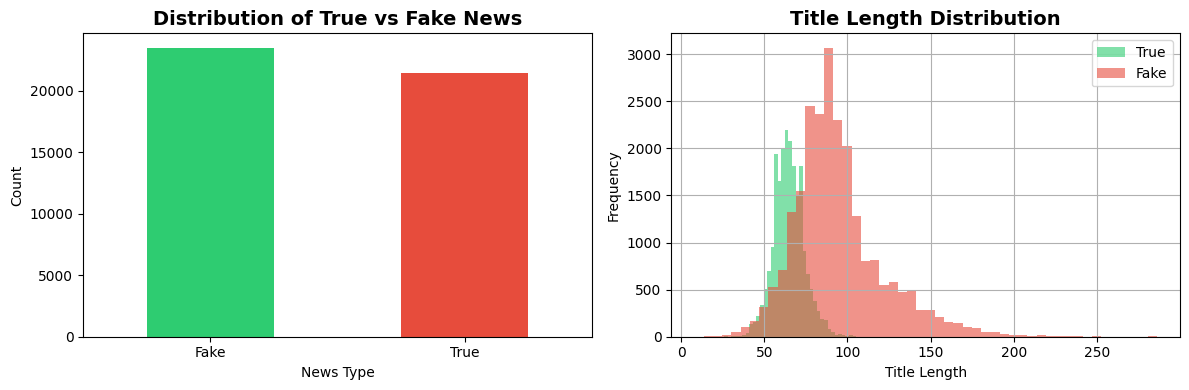


Train size: 31428
Val size: 6735
Test size: 6735

BERT MODEL

Epoch 1/2
  Batch    50 of   983
  Batch   100 of   983
  Batch   150 of   983
  Batch   200 of   983
  Batch   250 of   983
  Batch   300 of   983
  Batch   350 of   983
  Batch   400 of   983
  Batch   450 of   983
  Batch   500 of   983
  Batch   550 of   983
  Batch   600 of   983
  Batch   650 of   983
  Batch   700 of   983
  Batch   750 of   983
  Batch   800 of   983
  Batch   850 of   983
  Batch   900 of   983
  Batch   950 of   983
  Train Loss: 0.568
  Val Loss: 0.497

Epoch 2/2
  Batch    50 of   983
  Batch   100 of   983
  Batch   150 of   983
  Batch   200 of   983
  Batch   250 of   983
  Batch   300 of   983
  Batch   350 of   983
  Batch   400 of   983
  Batch   450 of   983
  Batch   500 of   983
  Batch   550 of   983
  Batch   600 of   983
  Batch   650 of   983
  Batch   700 of   983
  Batch   750 of   983
  Batch   800 of   983
  Batch   850 of   983
  Batch   900 of   983
  Batch   950 of   983
  Tr

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



DistilBERT Epoch 1/2
  Batch    50 of   983
  Batch   100 of   983
  Batch   150 of   983
  Batch   200 of   983
  Batch   250 of   983
  Batch   300 of   983
  Batch   350 of   983
  Batch   400 of   983
  Batch   450 of   983
  Batch   500 of   983
  Batch   550 of   983
  Batch   600 of   983
  Batch   650 of   983
  Batch   700 of   983
  Batch   750 of   983
  Batch   800 of   983
  Batch   850 of   983
  Batch   900 of   983
  Batch   950 of   983
  Train Loss: 0.115

DistilBERT Epoch 2/2
  Batch    50 of   983
  Batch   100 of   983
  Batch   150 of   983
  Batch   200 of   983
  Batch   250 of   983
  Batch   300 of   983
  Batch   350 of   983
  Batch   400 of   983
  Batch   450 of   983
  Batch   500 of   983
  Batch   550 of   983
  Batch   600 of   983
  Batch   650 of   983
  Batch   700 of   983
  Batch   750 of   983
  Batch   800 of   983
  Batch   850 of   983
  Batch   900 of   983
  Batch   950 of   983
  Train Loss: 0.038

DistilBERT Test Results:
              pr

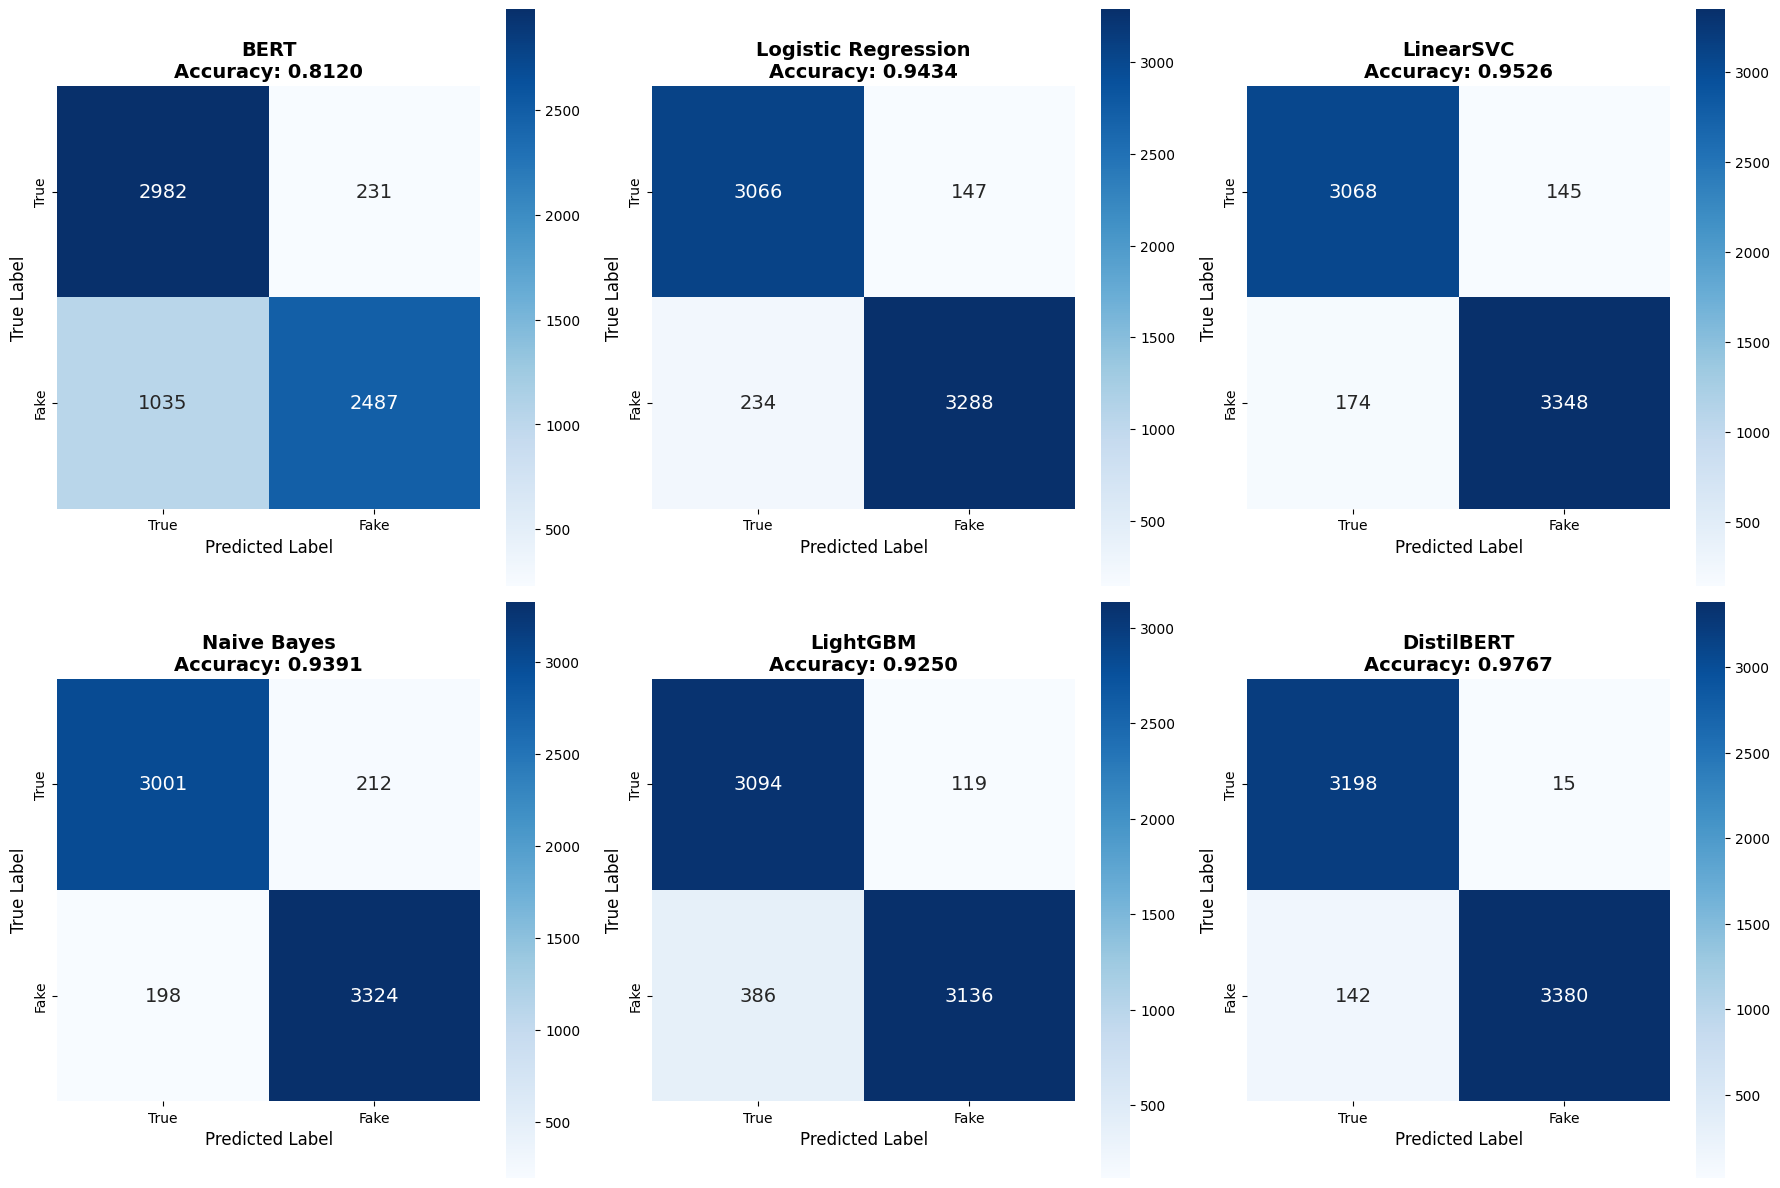


MODEL COMPARISON

               Model  Accuracy  Precision   Recall  F1-Score
               BERT  0.812027   0.915011 0.706133  0.797115
Logistic Regression  0.943430   0.957205 0.933560  0.945235
          LinearSVC  0.952635   0.958488 0.950596  0.954526
        Naive Bayes  0.939124   0.940045 0.943782  0.941910
           LightGBM  0.925019   0.963441 0.890403  0.925483
         DistilBERT  0.976689   0.995582 0.959682  0.977302


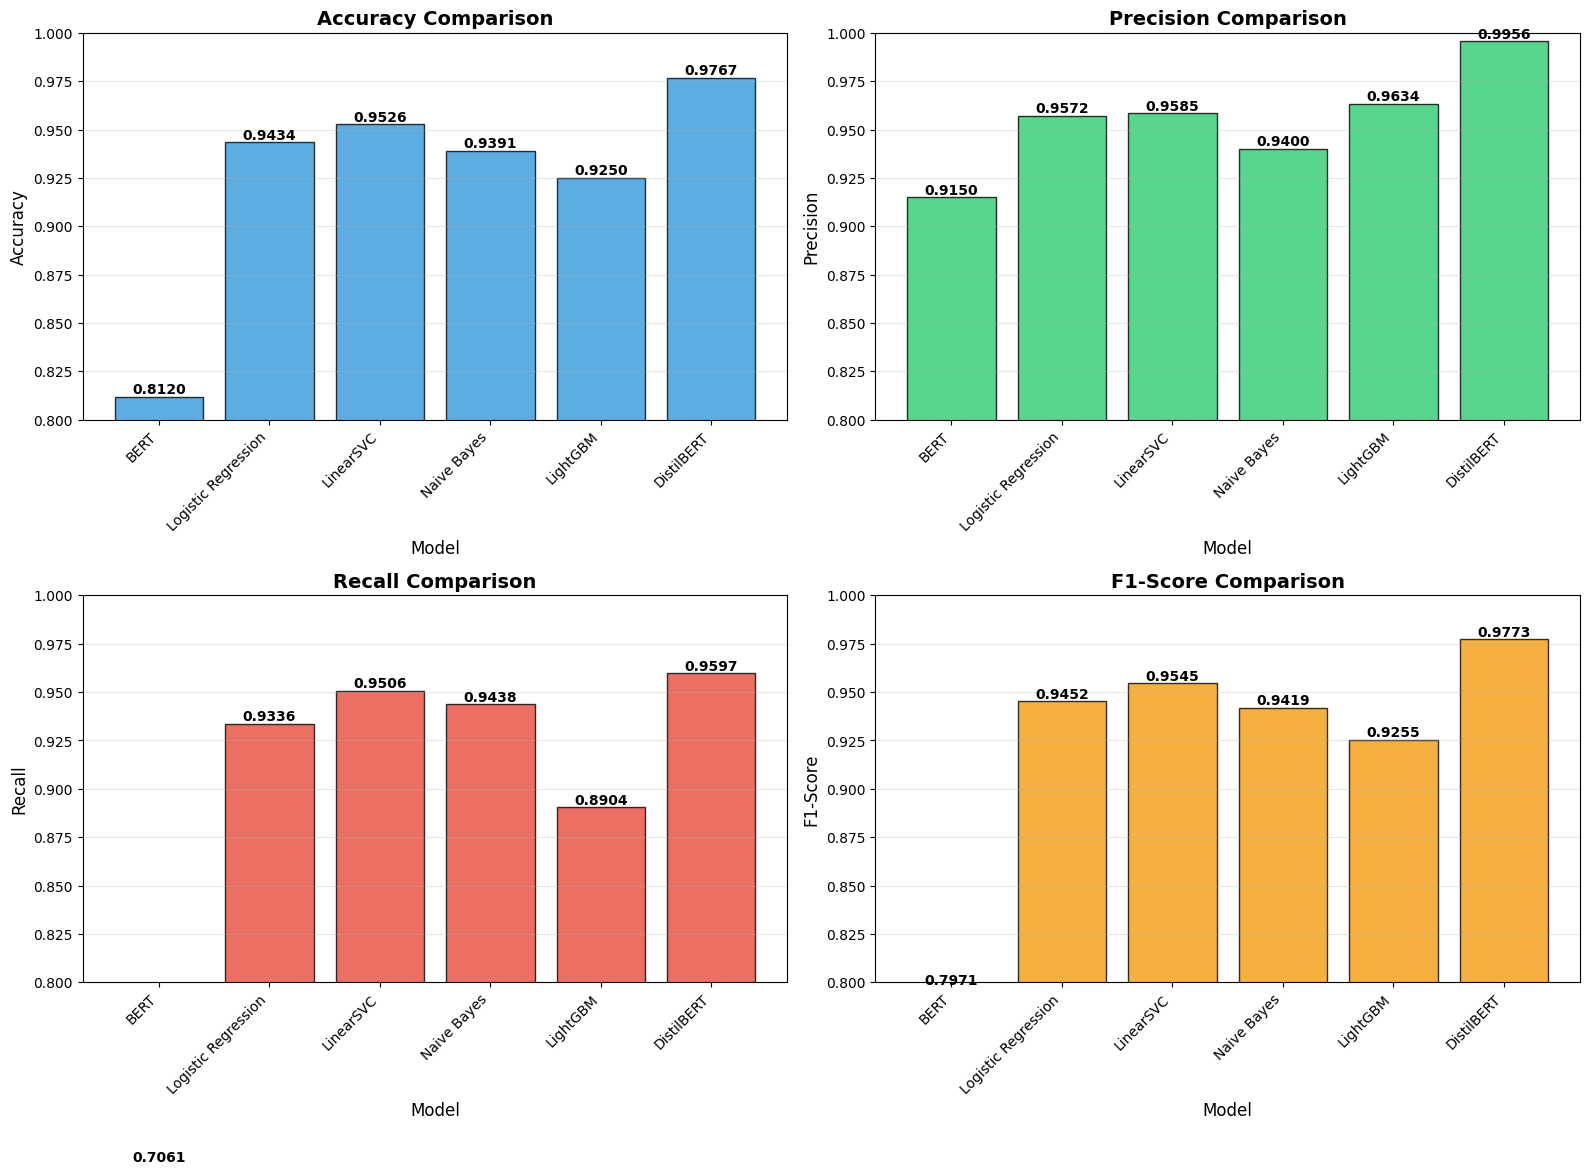

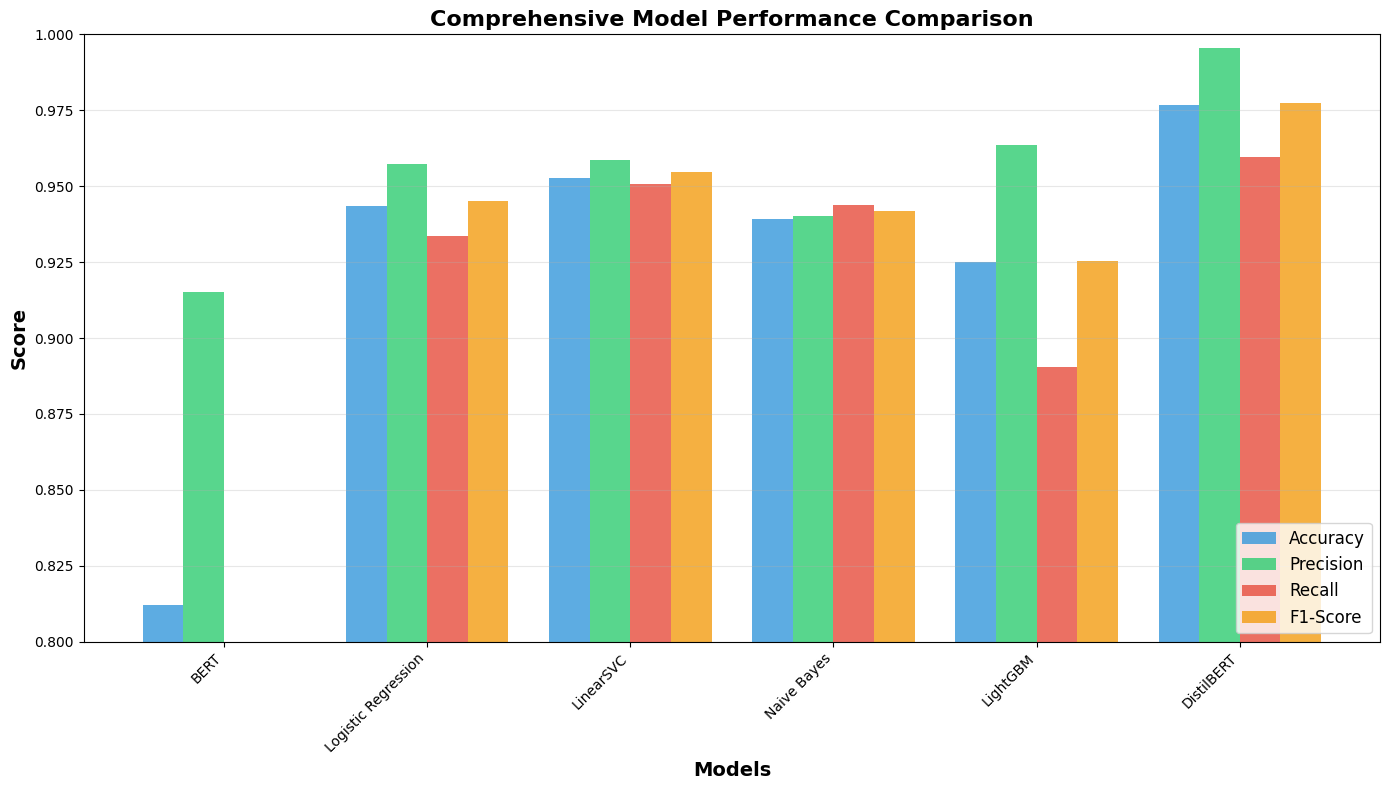


GENERATING ROC CURVES


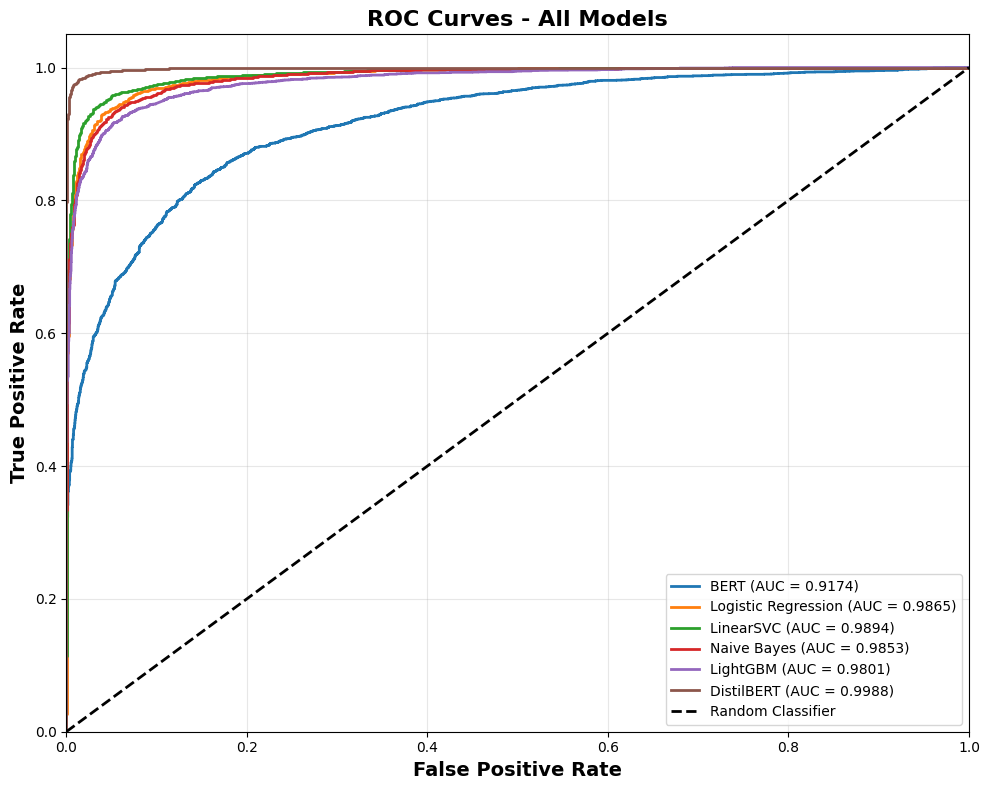


TRAINING HISTORY PLOTS


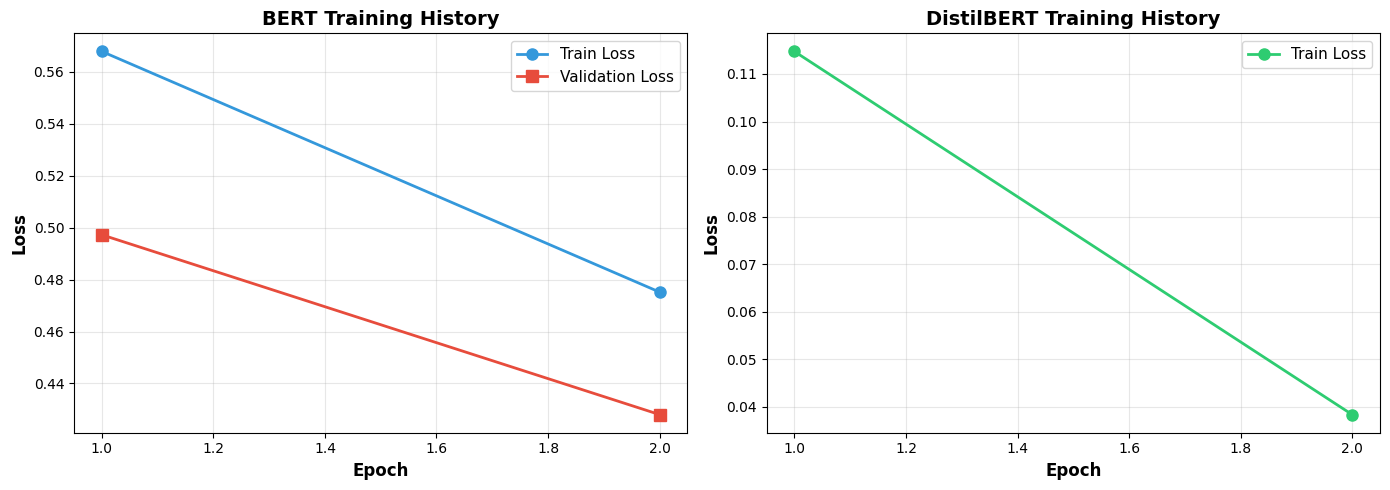


ERROR ANALYSIS


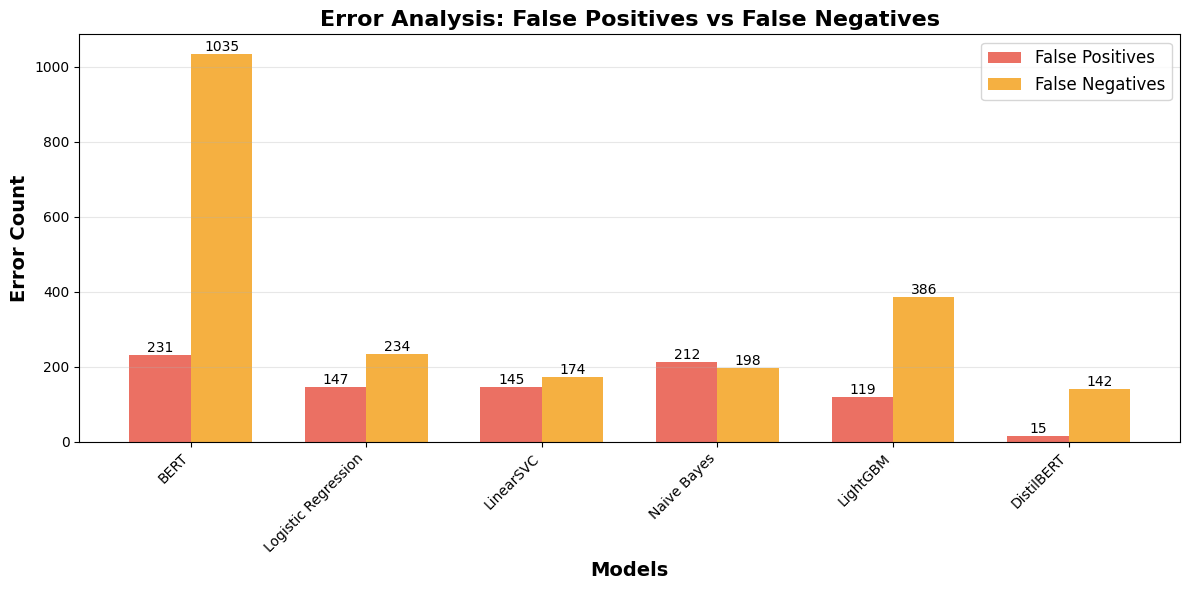


UNSEEN DATA PREDICTION

Predictions on Unseen Data:
                                                 News BERT Logistic Regression LinearSVC Naive Bayes LightGBM DistilBERT
Donald Trump Send out embarassing new year's eve m... True                Fake      Fake        Fake     Fake       True
           U.S. is not the superpower anymore now.... True                Fake      Fake        Fake     True       True
          New york city is the capital of New York... Fake                True      True        True     True       True
Albany, city, capital (1797) of the state of New Y... True                True      True        True     True       True
WATCH: Goerge W. Bush calls out Trump for Supporti... True                Fake      Fake        Fake     Fake       Fake
U.S. lawmakers question businessman at 2016 Trump ... True                True      True        True     True       True
Trump adminstration issues new rules on U.S. visa ... True                True      True        True

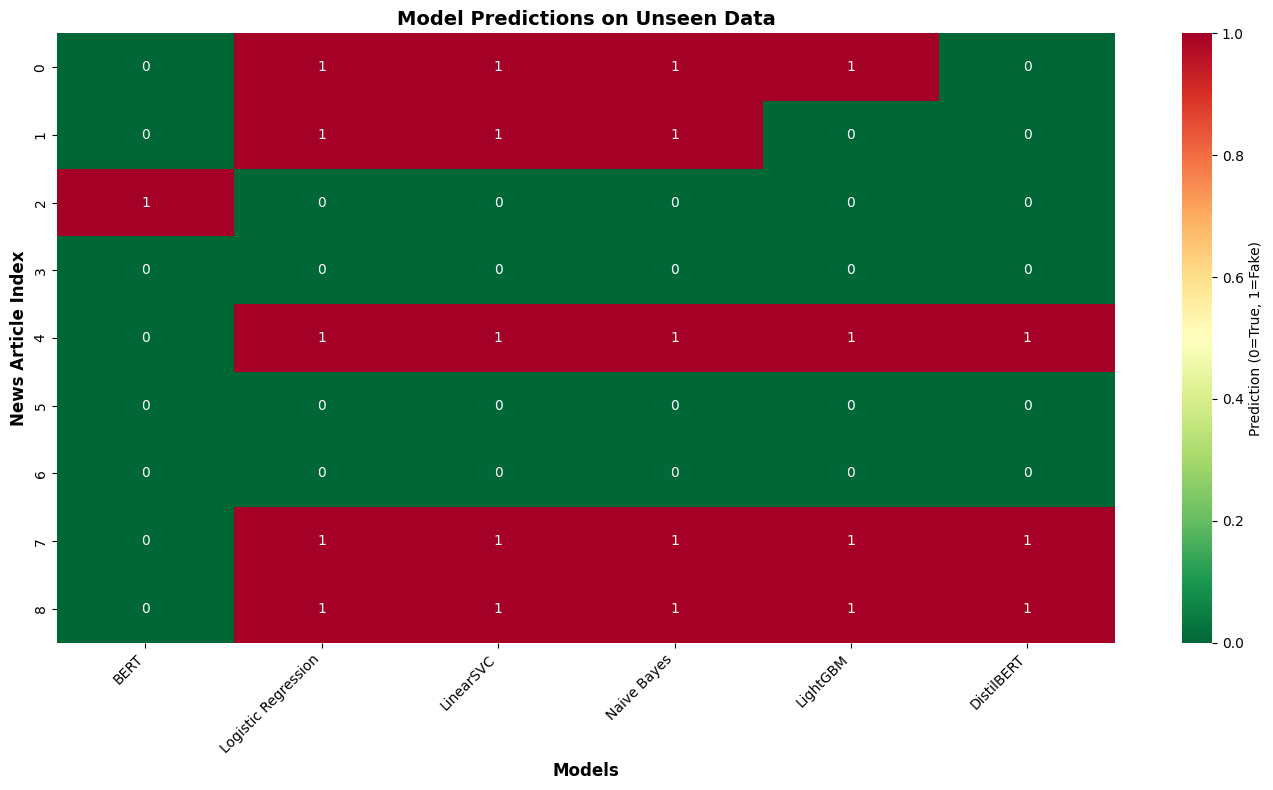


ALL VISUALIZATIONS COMPLETED!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler
from transformers import AutoModel, BertTokenizerFast, AdamW
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from lightgbm import LGBMClassifier
import sklearn.utils
import warnings
warnings.filterwarnings('ignore')

# Store results for comparison
model_results = {}

################################################################################
# 1. LOAD DATA
################################################################################
true = pd.read_csv("/kaggle/input/fake-and-real-news-dataset/True.csv")
fake = pd.read_csv("/kaggle/input/fake-and-real-news-dataset/Fake.csv")

print("True shape:", true.shape)
print("Fake shape:", fake.shape)

true['Target'] = 'True'
fake['Target'] = 'Fake'

true_fake = pd.concat([true, fake], ignore_index=True)
print("\nCombined shape:", true_fake.shape)

data = sklearn.utils.shuffle(true_fake).reset_index(drop=True)
print("After shuffle:", data.shape)

data['label'] = (data['Target'] == 'Fake').astype(int)
print("\nLabel distribution:\n", data['label'].value_counts())

# Visualize data distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data['Target'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution of True vs Fake News', fontsize=14, fontweight='bold')
axes[0].set_xlabel('News Type')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Text length distribution
data['text_length'] = data['title'].apply(len)
data[data['Target']=='True']['text_length'].hist(bins=50, alpha=0.6, label='True', color='#2ecc71', ax=axes[1])
data[data['Target']=='Fake']['text_length'].hist(bins=50, alpha=0.6, label='Fake', color='#e74c3c', ax=axes[1])
axes[1].set_title('Title Length Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Title Length')
axes[1].set_ylabel('Frequency')
axes[1].legend()
plt.tight_layout()
plt.savefig('data_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

################################################################################
# 2. TRAIN/VAL/TEST SPLIT
################################################################################
train_text, temp_text, train_labels, temp_labels = train_test_split(
    data['title'], 
    data['label'],
    random_state=2018,
    test_size=0.3,
    stratify=data['Target']
)

test_text, val_text, test_labels, val_labels = train_test_split(
    temp_text, 
    temp_labels,
    random_state=2018,
    test_size=0.5,
    stratify=temp_labels
)

print("\nTrain size:", train_text.shape[0])
print("Val size:", val_text.shape[0])
print("Test size:", test_text.shape[0])

################################################################################
# 3. BERT MODEL (Model 1)
################################################################################
print("\n" + "="*80)
print("BERT MODEL")
print("="*80)

bert_model = AutoModel.from_pretrained('bert-base-uncased')
bert_tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

MAX_LENGTH = 15

tokens_train = bert_tokenizer.batch_encode_plus(
    train_text.tolist(),
    max_length=MAX_LENGTH,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)
tokens_val = bert_tokenizer.batch_encode_plus(
    val_text.tolist(),
    max_length=MAX_LENGTH,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)
tokens_test = bert_tokenizer.batch_encode_plus(
    test_text.tolist(),
    max_length=MAX_LENGTH,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

train_seq = tokens_train['input_ids']
train_mask = tokens_train['attention_mask']
train_y = torch.tensor(train_labels.tolist())

val_seq = tokens_val['input_ids']
val_mask = tokens_val['attention_mask']
val_y = torch.tensor(val_labels.tolist())

test_seq = tokens_test['input_ids']
test_mask = tokens_test['attention_mask']
test_y = torch.tensor(test_labels.tolist())

batch_size = 32
train_data = TensorDataset(train_seq, train_mask, train_y)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

val_data = TensorDataset(val_seq, val_mask, val_y)
val_sampler = RandomSampler(val_data)
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=batch_size)

for param in bert_model.parameters():
    param.requires_grad = False

class BERT_Arch(nn.Module):
    def __init__(self, bert):
        super(BERT_Arch, self).__init__()
        self.bert = bert
        self.dropout = nn.Dropout(0.1)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(768, 512)
        self.fc2 = nn.Linear(512, 2)
    
    def forward(self, sent_id, mask):
        cls_hs = self.bert(sent_id, attention_mask=mask)['pooler_output']
        x = self.fc1(cls_hs)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

bert_classifier = BERT_Arch(bert_model)
optimizer = AdamW(bert_classifier.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

# Store training history
bert_train_losses = []
bert_val_losses = []

def train_bert():
    bert_classifier.train()
    total_loss = 0
    for step, batch in enumerate(train_dataloader):
        if step % 50 == 0 and step != 0:
            print(f'  Batch {step:>5,} of {len(train_dataloader):>5,}')
        sent_id, mask, labels = batch
        bert_classifier.zero_grad()
        preds = bert_classifier(sent_id, mask)
        loss = criterion(preds, labels)
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_classifier.parameters(), 1.0)
        optimizer.step()
    return total_loss / len(train_dataloader)

def evaluate_bert():
    bert_classifier.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in val_dataloader:
            sent_id, mask, labels = batch
            preds = bert_classifier(sent_id, mask)
            loss = criterion(preds, labels)
            total_loss += loss.item()
    return total_loss / len(val_dataloader)

epochs = 2
best_valid_loss = float('inf')

for epoch in range(epochs):
    print(f'\nEpoch {epoch+1}/{epochs}')
    train_loss = train_bert()
    valid_loss = evaluate_bert()
    bert_train_losses.append(train_loss)
    bert_val_losses.append(valid_loss)
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(bert_classifier.state_dict(), 'bert_weights.pt')
    print(f'  Train Loss: {train_loss:.3f}')
    print(f'  Val Loss: {valid_loss:.3f}')

bert_classifier.load_state_dict(torch.load('bert_weights.pt'))

bert_classifier.eval()
with torch.no_grad():
    bert_logits = bert_classifier(test_seq, test_mask)
    bert_probs = torch.softmax(bert_logits, dim=1).cpu().numpy()

bert_pred = bert_probs.argmax(axis=1)
print("\nBERT Test Results:")
print(classification_report(test_y.numpy(), bert_pred))

# Store BERT results
model_results['BERT'] = {
    'predictions': bert_pred,
    'probabilities': bert_probs,
    'accuracy': accuracy_score(test_y.numpy(), bert_pred),
    'precision': precision_score(test_y.numpy(), bert_pred),
    'recall': recall_score(test_y.numpy(), bert_pred),
    'f1': f1_score(test_y.numpy(), bert_pred),
    'confusion_matrix': confusion_matrix(test_y.numpy(), bert_pred)
}

################################################################################
# 4. CLASSICAL MODELS
################################################################################
print("\n" + "="*80)
print("CLASSICAL MODELS")
print("="*80)

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words='english')
X_train = tfidf.fit_transform(train_text)
X_val = tfidf.transform(val_text)
X_test = tfidf.transform(test_text)

# Model 2: Logistic Regression
print("\nTraining Logistic Regression...")
logreg = LogisticRegression(max_iter=2000, random_state=2018)
logreg.fit(X_train, train_labels)
logreg_proba = logreg.predict_proba(X_test)
logreg_pred = logreg_proba.argmax(axis=1)
print("Logistic Regression Test Results:")
print(classification_report(test_labels, logreg_pred))

model_results['Logistic Regression'] = {
    'predictions': logreg_pred,
    'probabilities': logreg_proba,
    'accuracy': accuracy_score(test_labels, logreg_pred),
    'precision': precision_score(test_labels, logreg_pred),
    'recall': recall_score(test_labels, logreg_pred),
    'f1': f1_score(test_labels, logreg_pred),
    'confusion_matrix': confusion_matrix(test_labels, logreg_pred)
}

# Model 3: LinearSVC
print("\nTraining LinearSVC...")
svm = LinearSVC(max_iter=2000, random_state=2018)
svm.fit(X_train, train_labels)
svm_decision = svm.decision_function(X_test)
svm_proba = 1 / (1 + np.exp(-svm_decision))
svm_proba = np.vstack([1 - svm_proba, svm_proba]).T
svm_pred = svm_proba.argmax(axis=1)
print("LinearSVC Test Results:")
print(classification_report(test_labels, svm_pred))

model_results['LinearSVC'] = {
    'predictions': svm_pred,
    'probabilities': svm_proba,
    'accuracy': accuracy_score(test_labels, svm_pred),
    'precision': precision_score(test_labels, svm_pred),
    'recall': recall_score(test_labels, svm_pred),
    'f1': f1_score(test_labels, svm_pred),
    'confusion_matrix': confusion_matrix(test_labels, svm_pred)
}

# Model 4: Multinomial Naive Bayes
print("\nTraining Multinomial Naive Bayes...")
nb = MultinomialNB()
nb.fit(X_train, train_labels)
nb_proba = nb.predict_proba(X_test)
nb_pred = nb_proba.argmax(axis=1)
print("Naive Bayes Test Results:")
print(classification_report(test_labels, nb_pred))

model_results['Naive Bayes'] = {
    'predictions': nb_pred,
    'probabilities': nb_proba,
    'accuracy': accuracy_score(test_labels, nb_pred),
    'precision': precision_score(test_labels, nb_pred),
    'recall': recall_score(test_labels, nb_pred),
    'f1': f1_score(test_labels, nb_pred),
    'confusion_matrix': confusion_matrix(test_labels, nb_pred)
}

# Model 5: LightGBM
print("\nTraining LightGBM...")
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=2018, verbose=-1)
lgbm.fit(X_train, train_labels)
lgbm_proba = lgbm.predict_proba(X_test)
lgbm_pred = lgbm_proba.argmax(axis=1)
print("LightGBM Test Results:")
print(classification_report(test_labels, lgbm_pred))

model_results['LightGBM'] = {
    'predictions': lgbm_pred,
    'probabilities': lgbm_proba,
    'accuracy': accuracy_score(test_labels, lgbm_pred),
    'precision': precision_score(test_labels, lgbm_pred),
    'recall': recall_score(test_labels, lgbm_pred),
    'f1': f1_score(test_labels, lgbm_pred),
    'confusion_matrix': confusion_matrix(test_labels, lgbm_pred)
}

################################################################################
# 5. DISTILBERT MODEL
################################################################################
print("\n" + "="*80)
print("DISTILBERT MODEL")
print("="*80)

distilbert_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
distilbert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

distil_tokens_train = distilbert_tokenizer.batch_encode_plus(
    train_text.tolist(),
    max_length=MAX_LENGTH,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)
distil_tokens_test = distilbert_tokenizer.batch_encode_plus(
    test_text.tolist(),
    max_length=MAX_LENGTH,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

distil_train_seq = distil_tokens_train['input_ids']
distil_train_mask = distil_tokens_train['attention_mask']
distil_test_seq = distil_tokens_test['input_ids']
distil_test_mask = distil_tokens_test['attention_mask']

distil_train_data = TensorDataset(distil_train_seq, distil_train_mask, train_y)
distil_train_loader = DataLoader(distil_train_data, batch_size=batch_size, shuffle=True)

distil_optimizer = AdamW(distilbert_model.parameters(), lr=2e-5)

# Store DistilBERT training history
distil_train_losses = []

distilbert_model.train()
for epoch in range(2):
    print(f'\nDistilBERT Epoch {epoch+1}/2')
    total_loss = 0
    for step, batch in enumerate(distil_train_loader):
        if step % 50 == 0 and step != 0:
            print(f'  Batch {step:>5,} of {len(distil_train_loader):>5,}')
        sent_id, mask, labels = batch
        distil_optimizer.zero_grad()
        outputs = distilbert_model(input_ids=sent_id, attention_mask=mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        distil_optimizer.step()
    avg_loss = total_loss/len(distil_train_loader)
    distil_train_losses.append(avg_loss)
    print(f'  Train Loss: {avg_loss:.3f}')

distilbert_model.eval()
with torch.no_grad():
    distil_outputs = distilbert_model(input_ids=distil_test_seq, attention_mask=distil_test_mask)
    distil_logits = distil_outputs.logits
    distil_probs = torch.softmax(distil_logits, dim=1).cpu().numpy()

distil_pred = distil_probs.argmax(axis=1)
print("\nDistilBERT Test Results:")
print(classification_report(test_y.numpy(), distil_pred))

model_results['DistilBERT'] = {
    'predictions': distil_pred,
    'probabilities': distil_probs,
    'accuracy': accuracy_score(test_y.numpy(), distil_pred),
    'precision': precision_score(test_y.numpy(), distil_pred),
    'recall': recall_score(test_y.numpy(), distil_pred),
    'f1': f1_score(test_y.numpy(), distil_pred),
    'confusion_matrix': confusion_matrix(test_y.numpy(), distil_pred)
}

################################################################################
# 6. VISUALIZATION - CONFUSION MATRICES FOR ALL MODELS
################################################################################
print("\n" + "="*80)
print("GENERATING CONFUSION MATRICES")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (model_name, results) in enumerate(model_results.items()):
    cm = results['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                cbar=True, square=True, annot_kws={'size': 14})
    axes[idx].set_title(f'{model_name}\nAccuracy: {results["accuracy"]:.4f}', 
                       fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=12)
    axes[idx].set_ylabel('True Label', fontsize=12)
    axes[idx].set_xticklabels(['True', 'Fake'])
    axes[idx].set_yticklabels(['True', 'Fake'])

plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

################################################################################
# 7. MODEL COMPARISON - PERFORMANCE METRICS
################################################################################
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Accuracy': [results['accuracy'] for results in model_results.values()],
    'Precision': [results['precision'] for results in model_results.values()],
    'Recall': [results['recall'] for results in model_results.values()],
    'F1-Score': [results['f1'] for results in model_results.values()]
})

print("\n", comparison_df.to_string(index=False))

# Bar plot comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=color, alpha=0.8, edgecolor='black')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylim([0.8, 1.0])
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Grouped bar chart for all metrics
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(comparison_df['Model']))
width = 0.2

bars1 = ax.bar(x - 1.5*width, comparison_df['Accuracy'], width, label='Accuracy', color='#3498db', alpha=0.8)
bars2 = ax.bar(x - 0.5*width, comparison_df['Precision'], width, label='Precision', color='#2ecc71', alpha=0.8)
bars3 = ax.bar(x + 0.5*width, comparison_df['Recall'], width, label='Recall', color='#e74c3c', alpha=0.8)
bars4 = ax.bar(x + 1.5*width, comparison_df['F1-Score'], width, label='F1-Score', color='#f39c12', alpha=0.8)

ax.set_xlabel('Models', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_title('Comprehensive Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend(loc='lower right', fontsize=12)
ax.set_ylim([0.8, 1.0])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

################################################################################
# 8. ROC CURVES
################################################################################
print("\n" + "="*80)
print("GENERATING ROC CURVES")
print("="*80)

plt.figure(figsize=(10, 8))

for model_name, results in model_results.items():
    probs = results['probabilities'][:, 1]
    fpr, tpr, _ = roc_curve(test_y.numpy(), probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC Curves - All Models', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

################################################################################
# 9. TRAINING HISTORY
################################################################################
print("\n" + "="*80)
print("TRAINING HISTORY PLOTS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BERT training history
axes[0].plot(range(1, len(bert_train_losses) + 1), bert_train_losses, 
             marker='o', linewidth=2, markersize=8, label='Train Loss', color='#3498db')
axes[0].plot(range(1, len(bert_val_losses) + 1), bert_val_losses, 
             marker='s', linewidth=2, markersize=8, label='Validation Loss', color='#e74c3c')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('BERT Training History', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# DistilBERT training history
axes[1].plot(range(1, len(distil_train_losses) + 1), distil_train_losses, 
             marker='o', linewidth=2, markersize=8, label='Train Loss', color='#2ecc71')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('DistilBERT Training History', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

################################################################################
# 10. ERROR ANALYSIS
################################################################################
print("\n" + "="*80)
print("ERROR ANALYSIS")
print("="*80)

# Calculate error rates for each model
error_rates = {}
for model_name, results in model_results.items():
    cm = results['confusion_matrix']
    false_positives = cm[0, 1]
    false_negatives = cm[1, 0]
    total = cm.sum()
    error_rates[model_name] = {
        'False Positives': false_positives,
        'False Negatives': false_negatives,
        'Total Errors': false_positives + false_negatives,
        'Error Rate': (false_positives + false_negatives) / total
    }

# Visualize error types
fig, ax = plt.subplots(figsize=(12, 6))
models = list(error_rates.keys())
fp = [error_rates[m]['False Positives'] for m in models]
fn = [error_rates[m]['False Negatives'] for m in models]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, fp, width, label='False Positives', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, fn, width, label='False Negatives', color='#f39c12', alpha=0.8)

ax.set_xlabel('Models', fontsize=14, fontweight='bold')
ax.set_ylabel('Error Count', fontsize=14, fontweight='bold')
ax.set_title('Error Analysis: False Positives vs False Negatives', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

################################################################################
# 11. PREDICTION ON UNSEEN DATA
################################################################################
print("\n" + "="*80)
print("UNSEEN DATA PREDICTION")
print("="*80)

unseen_news_text = [
    "Donald Trump Send out embarassing new year's eve message; This is disturbing",
    "U.S. is not the superpower anymore now.",
    "New york city is the capital of New York",
    "Albany, city, capital (1797) of the state of New York.",
    "WATCH: Goerge W. Bush calls out Trump for Supporting White Supremacy",
    "U.S. lawmakers question businessman at 2016 Trump Tower meeting: sources",
    "Trump adminstration issues new rules on U.S. visa waivers",
    "New York state of the United States of America, one of the 13 original colonies and states.",
    "DOJ demands list of thousands of FBI employees who worked on January 6 and Trump investigations"
]

# Collect predictions from all models
unseen_predictions = {}

# BERT
tokens_unseen = bert_tokenizer.batch_encode_plus(
    unseen_news_text, max_length=MAX_LENGTH, padding='max_length', 
    truncation=True, return_tensors='pt'
)
bert_classifier.eval()
with torch.no_grad():
    bert_unseen_logits = bert_classifier(tokens_unseen['input_ids'], tokens_unseen['attention_mask'])
    bert_unseen_probs = torch.softmax(bert_unseen_logits, dim=1).cpu().numpy()
unseen_predictions['BERT'] = bert_unseen_probs.argmax(axis=1)

# Classical models
X_unseen = tfidf.transform(unseen_news_text)
unseen_predictions['Logistic Regression'] = logreg.predict(X_unseen)
unseen_predictions['LinearSVC'] = svm.predict(X_unseen)
unseen_predictions['Naive Bayes'] = nb.predict(X_unseen)
unseen_predictions['LightGBM'] = lgbm.predict(X_unseen)

# DistilBERT
distil_tokens_unseen = distilbert_tokenizer.batch_encode_plus(
    unseen_news_text, max_length=MAX_LENGTH, padding='max_length',
    truncation=True, return_tensors='pt'
)
distilbert_model.eval()
with torch.no_grad():
    distil_unseen_outputs = distilbert_model(
        input_ids=distil_tokens_unseen['input_ids'],
        attention_mask=distil_tokens_unseen['attention_mask']
    )
    distil_unseen_probs = torch.softmax(distil_unseen_outputs.logits, dim=1).cpu().numpy()
unseen_predictions['DistilBERT'] = distil_unseen_probs.argmax(axis=1)

# Create prediction table
pred_df = pd.DataFrame(unseen_predictions)
pred_df['News'] = [text[:50] + '...' for text in unseen_news_text]
pred_df = pred_df[['News'] + list(unseen_predictions.keys())]

# Replace 0/1 with True/Fake
for col in pred_df.columns[1:]:
    pred_df[col] = pred_df[col].map({0: 'True', 1: 'Fake'})

print("\nPredictions on Unseen Data:")
print(pred_df.to_string(index=False))

# Visualize prediction agreement
fig, ax = plt.subplots(figsize=(14, 8))
pred_matrix = np.array([unseen_predictions[model] for model in model_results.keys()]).T
sns.heatmap(pred_matrix, annot=True, fmt='d', cmap='RdYlGn_r', ax=ax, 
            cbar_kws={'label': 'Prediction (0=True, 1=Fake)'})
ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('News Article Index', fontsize=12, fontweight='bold')
ax.set_title('Model Predictions on Unseen Data', fontsize=14, fontweight='bold')
ax.set_xticklabels(list(model_results.keys()), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('unseen_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("ALL VISUALIZATIONS COMPLETED!")
print("="*80)